In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.svm import LinearSVC
from sklearn.linear_model import RidgeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import warnings

# Settings
warnings.filterwarnings('ignore')
sns.set(style="whitegrid", palette="muted")

In [3]:
# ==========================================
# 1. DATA LOADING & 1/4 SUBSAMPLING
# ==========================================
df_full = pd.read_csv('data.csv', encoding='ISO-8859-1')

# Exactly 25% (1/4) of the data
df = df_full.sample(frac=0.25, random_state=55).reset_index(drop=True)
print(f"Dataset Sampled to 1/4: {df.shape}")

Dataset Sampled to 1/4: (135477, 8)


In [4]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,571636,20676,RED RETROSPOT BOWL,16,10/18/2011 11:41,1.25,13509.0,United Kingdom
1,580727,23292,SPACEBOY CHILDRENS CUP,1,12/5/2011 17:17,2.46,14096.0,United Kingdom
2,548808,21231,SWEETHEART CERAMIC TRINKET BOX,4,4/4/2011 12:55,1.25,17774.0,United Kingdom
3,554265,21931,JUMBO STORAGE BAG SUKI,1,5/23/2011 12:38,2.08,NaN,United Kingdom
4,558556,21914,BLUE HARMONICA IN BOX,1,6/30/2011 13:14,1.25,17954.0,United Kingdom


In [5]:
df.tail()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
135472,573576,21028,NINJA RABBIT BLACK,1,10/31/2011 14:09,2.46,14096.0,United Kingdom
135473,565726,23174,REGENCY SUGAR BOWL GREEN,4,9/6/2011 11:58,4.15,14360.0,United Kingdom
135474,572726,22952,60 CAKE CASES VINTAGE CHRISTMAS,6,10/25/2011 15:19,0.55,16056.0,United Kingdom
135475,580983,23007,SPACEBOY BABY GIFT SET,1,12/6/2011 16:26,10.79,NaN,United Kingdom
135476,559680,22961,JAM MAKING SET PRINTED,12,7/11/2011 14:47,1.45,12717.0,Greece


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 135477 entries, 0 to 135476
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    135477 non-null  object 
 1   StockCode    135477 non-null  object 
 2   Description  135123 non-null  object 
 3   Quantity     135477 non-null  int64  
 4   InvoiceDate  135477 non-null  object 
 5   UnitPrice    135477 non-null  float64
 6   CustomerID   101829 non-null  float64
 7   Country      135477 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 8.3+ MB


In [8]:
df_eda = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)].copy()
df_eda['InvoiceDate'] = pd.to_datetime(df_eda['InvoiceDate'])
df_eda['Revenue'] = df_eda['Quantity'] * df_eda['UnitPrice']
df_eda['Month'] = df_eda['InvoiceDate'].dt.month
df_eda['Hour'] = df_eda['InvoiceDate'].dt.hour
df_eda['Day'] = df_eda['InvoiceDate'].dt.day_name()
df_eda['Quarter'] = df_eda['InvoiceDate'].dt.quarter

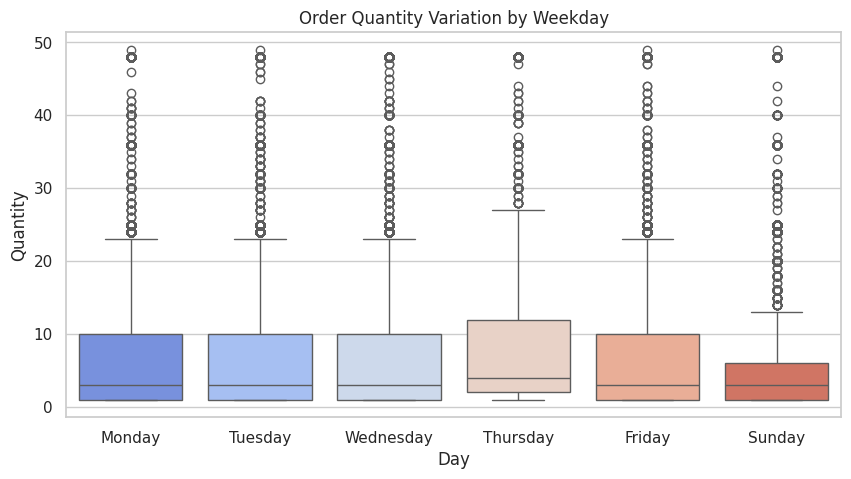

In [9]:
plt.figure(figsize=(10, 5))
sns.boxplot(x='Day', y='Quantity', data=df_eda[df_eda['Quantity'] < 50],
            order=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Sunday'], palette='coolwarm')
plt.title('Order Quantity Variation by Weekday')
plt.show()

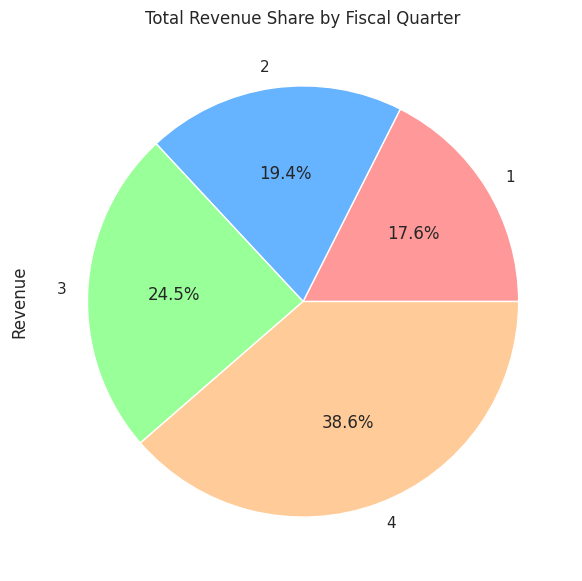

In [10]:
plt.figure(figsize=(7, 7))
df_eda.groupby('Quarter')['Revenue'].sum().plot(kind='pie', autopct='%1.1f%%', colors=['#ff9999','#66b3ff','#99ff99','#ffcc99'])
plt.title('Total Revenue Share by Fiscal Quarter')
plt.show()

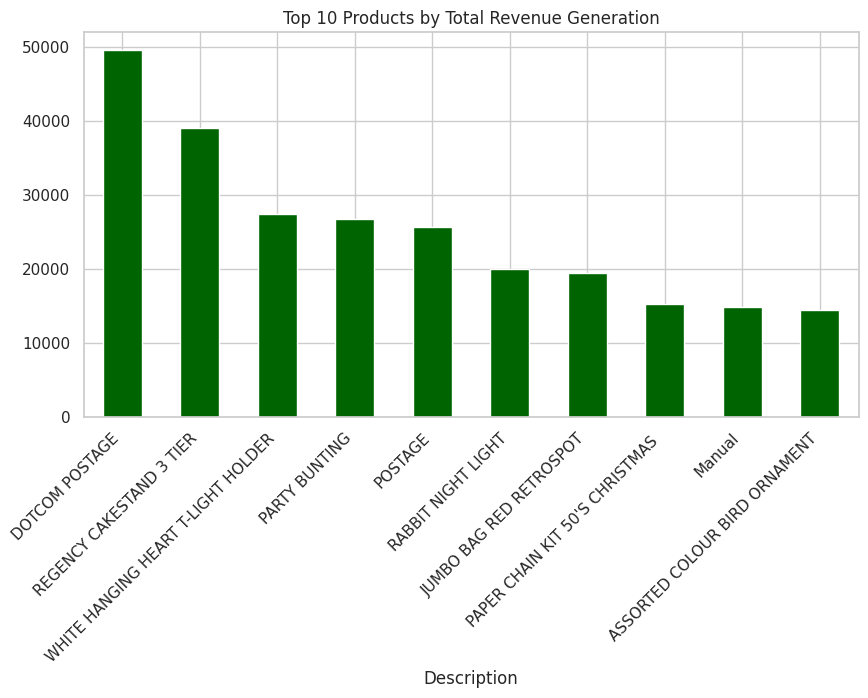

In [11]:
plt.figure(figsize=(10, 5))
df_eda.groupby('Description')['Revenue'].sum().sort_values(ascending=False).head(10).plot(kind='bar', color='darkgreen')
plt.title('Top 10 Products by Total Revenue Generation')
plt.xticks(rotation=45, ha='right')
plt.show()

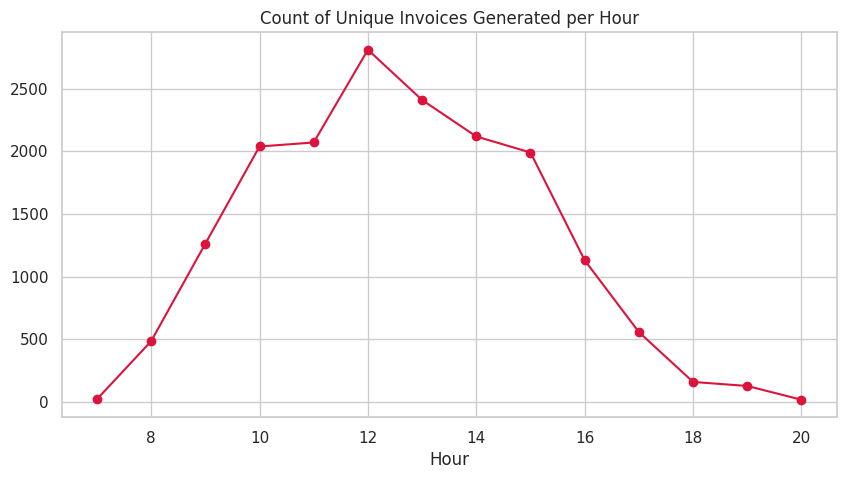

In [12]:
plt.figure(figsize=(10, 5))
df_eda.groupby('Hour')['InvoiceNo'].nunique().plot(kind='line', marker='o', color='crimson')
plt.title('Count of Unique Invoices Generated per Hour')
plt.show()

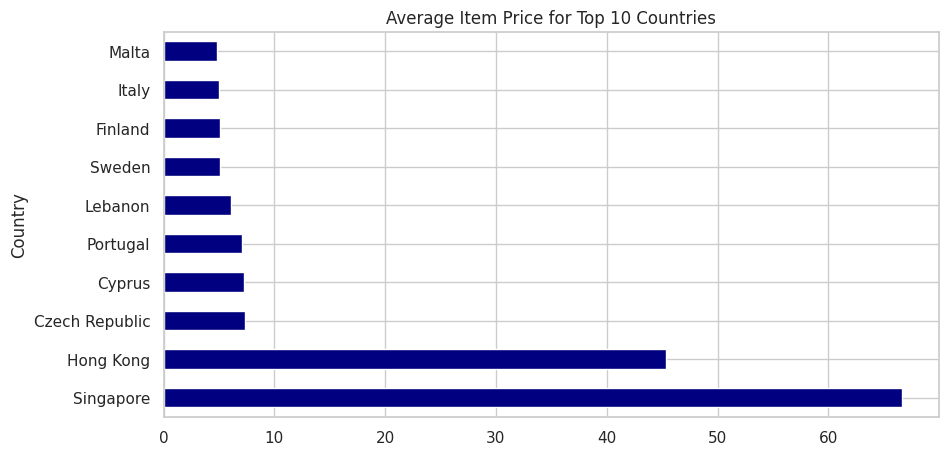

In [13]:
plt.figure(figsize=(10, 5))
df_eda.groupby('Country')['UnitPrice'].mean().sort_values(ascending=False).head(10).plot(kind='barh', color='navy')
plt.title('Average Item Price for Top 10 Countries')
plt.show()

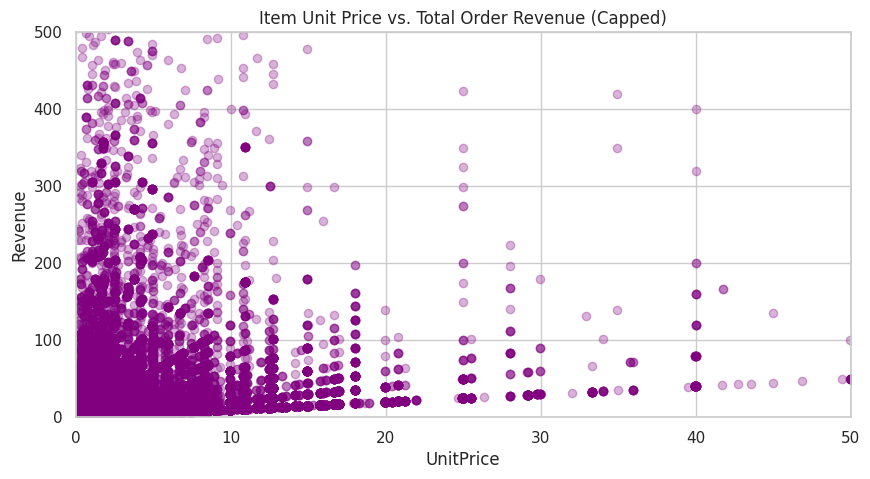

In [14]:
plt.figure(figsize=(10, 5))
plt.scatter(df_eda['UnitPrice'], df_eda['Revenue'], alpha=0.3, color='purple')
plt.title('Item Unit Price vs. Total Order Revenue (Capped)')
plt.xlabel('UnitPrice'); plt.ylabel('Revenue')
plt.xlim(0, 50); plt.ylim(0, 500)
plt.show()

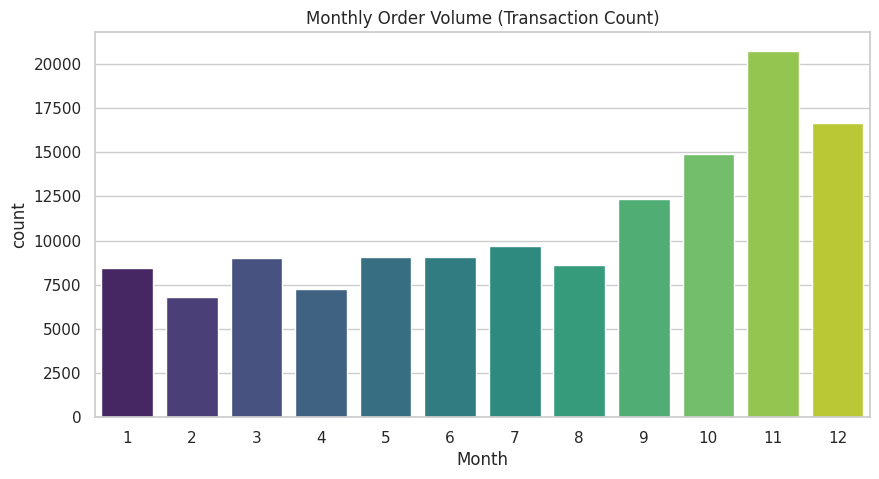

In [15]:
plt.figure(figsize=(10, 5))
sns.countplot(x='Month', data=df_eda, palette='viridis')
plt.title('Monthly Order Volume (Transaction Count)')
plt.show()

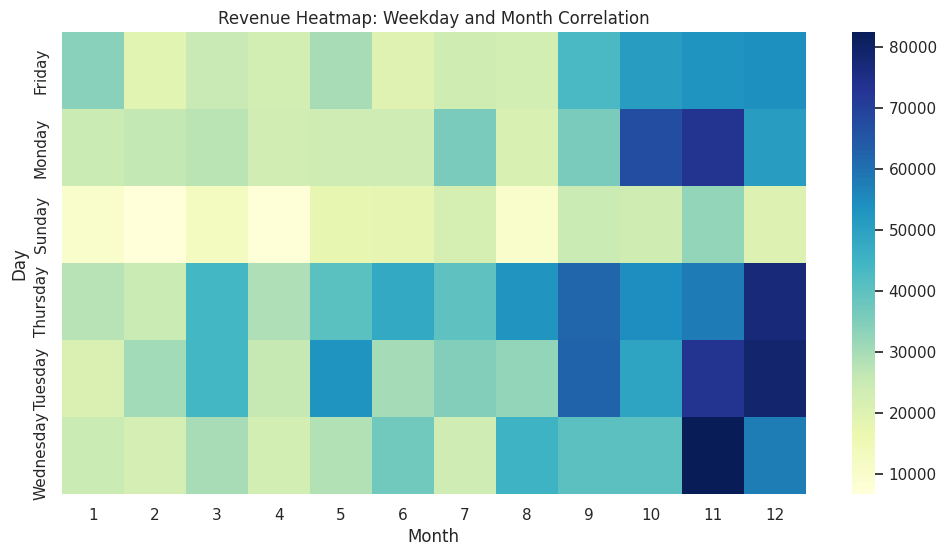

In [16]:
plt.figure(figsize=(12, 6))
heatmap_data = df_eda.pivot_table(index='Day', columns='Month', values='Revenue', aggfunc='sum')
sns.heatmap(heatmap_data, cmap='YlGnBu')
plt.title('Revenue Heatmap: Weekday and Month Correlation')
plt.show()

In [17]:
# ==========================================
# 3. PREPROCESSING & RANDOM OVER SAMPLING
# ==========================================
# Target: Is it a High Spend Order? (> $25)
df['IsHighSpend'] = ((df['Quantity'] * df['UnitPrice']) > 25).astype(int)
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['Hour'] = df['InvoiceDate'].dt.hour
df['Month'] = df['InvoiceDate'].dt.month

X = df[['Quantity', 'UnitPrice', 'Hour', 'Month']].fillna(0)
y = df['IsHighSpend']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=55)

# --- MANUAL RANDOM OVER SAMPLING ---
train_data = pd.concat([X_train, y_train], axis=1)
majority = train_data[train_data['IsHighSpend'] == 0]
minority = train_data[train_data['IsHighSpend'] == 1]

# Oversample the High Spend minority class
minority_upsampled = minority.sample(len(majority), replace=True, random_state=55)
balanced_df = pd.concat([majority, minority_upsampled]).sample(frac=1)

X_train_res = balanced_df.drop('IsHighSpend', axis=1)
y_train_res = balanced_df['IsHighSpend']

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)

In [18]:
# ==========================================
# 4. 3 ML MODELS & COMPARISON (STUDENT 3)
# ==========================================
models = {
    "Extra Trees": ExtraTreesClassifier(n_estimators=100, random_state=55),
    "Linear SVC": LinearSVC(random_state=55),
    "Ridge Classifier": RidgeClassifier()
}

results = []
for name, model in models.items():
    model.fit(X_train_scaled, y_train_res)
    preds = model.predict(X_test_scaled)
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, preds),
        "Precision": precision_score(y_test, preds),
        "Recall": recall_score(y_test, preds),
        "F1-Score": f1_score(y_test, preds)
    })

In [19]:
# Ranking
results_df = pd.DataFrame(results).sort_values(by='Accuracy', ascending=False).reset_index(drop=True)
results_df.index += 1
print("\n---MODEL PERFORMANCE RANKING ---")
print(results_df)


---MODEL PERFORMANCE RANKING ---
              Model  Accuracy  Precision    Recall  F1-Score
1       Extra Trees  0.994206   0.984075  0.973120  0.978567
2        Linear SVC  0.720660   0.267305  0.606028  0.370980
3  Ridge Classifier  0.590124   0.179407  0.563942  0.272215


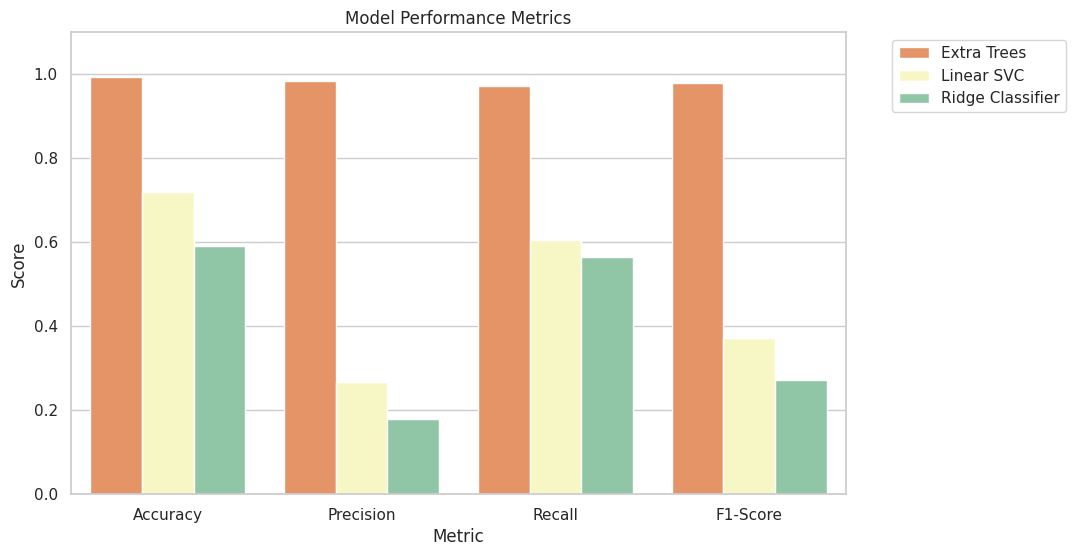

In [20]:
# Final Metrics Visualization
plt.figure(figsize=(10, 6))
metrics_melt = results_df.melt(id_vars="Model", var_name="Metric", value_name="Score")
sns.barplot(x='Metric', y='Score', hue='Model', data=metrics_melt, palette='Spectral')
plt.title('Model Performance Metrics')
plt.ylim(0, 1.1)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()